2024 3D 데이터처리 Homework 2

In [63]:
!pip install open3d

In [64]:
import numpy as np
import open3d as o3d
import plotly.graph_objects as go
from google.colab import drive
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
%cd /content/drive/MyDrive/'3ddp_calibration'/
!ls

/content/drive/MyDrive/3ddp_calibration
'3DDP24_E4_Stereo Matching.pptx'      left.jpg
 Calibration_Open3D_2024_ver2.ipynb   right.png
 checkboard			     'Stereo Matching 보고서.gdoc'
 depth.png			      stereo_skeleton_2024ver.ipynb
 khu.jpg			      stereo_skeleton_2024ver_____.ipynb


# Stereo Practice H.W 2

## 1. 사용할 카메라 intrinsic parameters 입력
* 이전 실습에 사용한 camera calibration 참고
* 혹은, https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html 자료 참고

In [79]:
import glob

# 패턴 정보
nH = 9
nV = 6
# 실제 크기에 맞게 쓰세요
nSize = 26.111

#  image names
images = glob.glob('./checkboard/*.jpg')

print((cv2.imread(images[0])).shape)

CHECKERBOARD = (nV,nH)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
# 각 체커보드 이미지에 대한 3D 점 벡터를 저장할 벡터 생성
objpoints = []
# 각 체커보드 이미지에 대한 2D 점 벡터를 저장할 벡터 생성
imgpoints = []
# 3D 점의 세계 좌표 정의
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2) * nSize
prev_img_shape = None
count = 0
for fname in images:
    img = cv2.imread(fname)
    img = cv2.resize(img,dsize = (img.shape[1]//4,img.shape[0]//4),interpolation=cv2.INTER_LINEAR)
    # if(img.shape[0]!= 3024 and img.shape[1] != 4032):
    #   continue
    count+=1
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray,
                                             CHECKERBOARD,
                                             cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)

    if ret == True:
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
        imgpoints.append(corners2)
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
    cv2_imshow(cv2.resize(img,  dsize=(0, 0), fx=0.4, fy=0.4, interpolation=cv2.INTER_LINEAR))
print(f"{count} pictures used!!")
h,w = img.shape[:2]
print(f"image size : {h,w}")
# 알려진 3D 점(objpoints) 값과 감지된 코너의 해당 픽셀 좌표(imgpoints) 전달, 카메라 캘리브레이션 수행
ret, intrinsic, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

# K 와 dist 값은 직접 입력하세요
K = intrinsic

# 두 값을 출력하세요 (숙제 항목)
print("\n-----Intrinsic Parameter-----")
print(K)
print("\n-----Distortion Parameter-----")
print(dist)

Output hidden; open in https://colab.research.google.com to view.

## 2. Stereo 사진 촬영
* 3D 복원에 사용할 stereo 사진 촬영
* Stereo Rectify 진행
* 주의사항: 하나의 카메라를 움직여 가며 사진을 촬영하면, 왼쪽과 오른쪽 카메라 좌표계 사이의 extrinsic parameters를 정확히 찾기 어렵습니다. 따라서 가능한 카메라를 바닥에 두고 **'x 축'으로만 움직여서 촬영**하세요.
* (정확히는 두 카메라 사이의 R,t도 추정해야 합니다. 그러나, 현재까지 배운 내용을 벗어나기 때문에 임의로 R,t를 쉽게 고정하는 의미입니다.)


In [84]:
# R: [3×3 double]
# T: [3×1 double]

# 촬영된 이미지를 불러옵니다.
rgb_left = cv2.imread('left.png')
rgb_right = cv2.imread('right.png')

print('Original Images')

rgb_left = cv2.resize(rgb_left,dsize = (rgb_left.shape[1]//4,rgb_left.shape[0]//4),interpolation=cv2.INTER_LINEAR)
rgb_right = cv2.resize(rgb_right,dsize = (rgb_right.shape[1]//4,rgb_right.shape[0]//4),interpolation=cv2.INTER_LINEAR)

concatenated_image = cv2.hconcat([rgb_left, rgb_right])
print(concatenated_image.shape)
cv2_imshow(concatenated_image)

h, w, c = rgb_left.shape

# 움직인 거리로 수정하세요
R = np.eye(3).astype(np.float64)
T = np.array([[10],[0],[0]], dtype=np.float64)

print("-----Extrinsic Parameter-----")
print("Rotation Matrix")
print(R)
print("Translation Matrix")
print(T)
print()

# Stereo imgae rectify 진행
# Hint: cv2.steroRectitfy, cv2.initUndistortRectifyMap 사용

SIZE = (w,h)

R1,R2,P1,P2,Q,_,_=cv2.stereoRectify(K,dist,K,dist,SIZE,R,T)

print("---camera 1---")
print("R1 \n",R1)
print("P1 \n",P1)
print("---camera 2---")
print("R2 \n",R2)
print("P2 \n",P2)

map1x, map1y = cv2.initUndistortRectifyMap(K,dist,R1,P1, SIZE,cv2.CV_32FC1)
map2x, map2y = cv2.initUndistortRectifyMap(K,dist,R2,P2, SIZE,cv2.CV_32FC1)

img1_rect = cv2.remap(rgb_left, map1x, map1y, cv2.INTER_LINEAR)
img2_rect = cv2.remap(rgb_right, map2x, map2y, cv2.INTER_LINEAR)


print('Stereo Rectified Images')
print((cv2.hconcat([img1_rect, img2_rect])).shape)
cv2_imshow(cv2.hconcat([img1_rect, img2_rect]))

Output hidden; open in https://colab.research.google.com to view.

## 3. Disparity Map 구하기

<class 'numpy.ndarray'>
int16


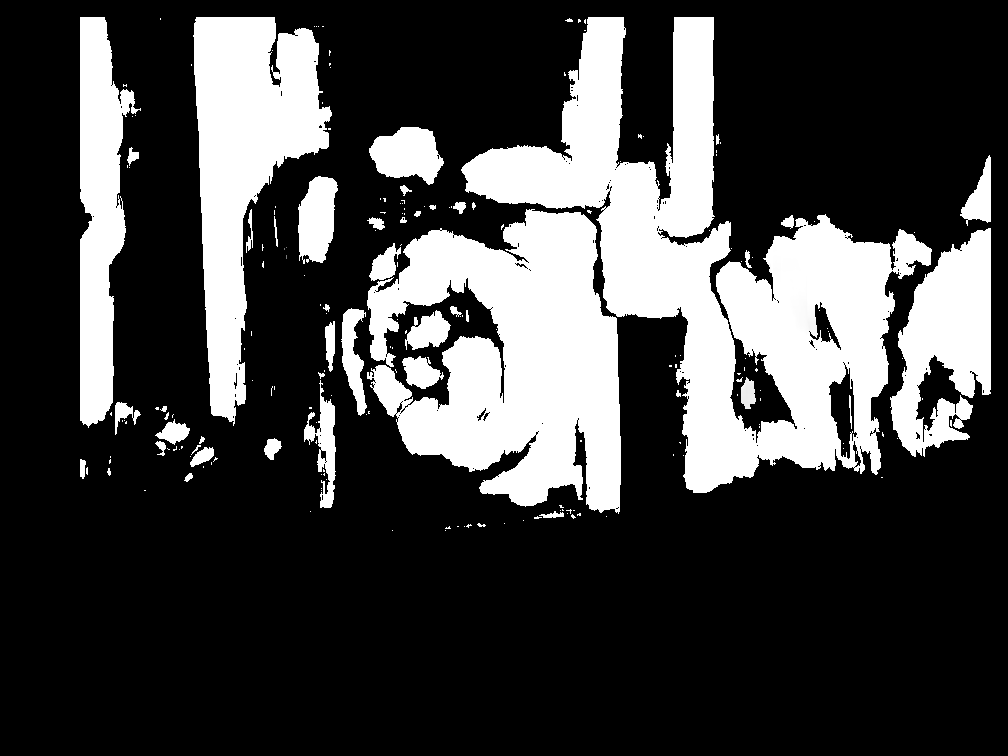

In [72]:
grayL  = cv2.cvtColor(img1_rect,cv2.COLOR_BGR2GRAY)
grayR  = cv2.cvtColor(img2_rect,cv2.COLOR_BGR2GRAY)


# Disparity map 구하기
# Hint: SteroBM_create 사용

stereo = cv2.StereoBM_create(numDisparities = 64, blockSize = 35)
disparity = stereo.compute(grayL,grayR)

print(type(disparity))
print(disparity.dtype)

disparity.astype(np.uint8)
cv2_imshow(disparity)


## 4. 3차원 복원

In [89]:
colors = []
points = []

f_x = K[0,0]
f_y = K[1,1]
c_x = K[0,2]
c_y = K[1,2]

sampling_rate = 1
for v in range(0,h,sampling_rate):
  for u in range(0,w,sampling_rate):
    if disparity[v,u] < 0:
      continue
    color = img1_rect[int(v),int(u),:]
    if color[2] == 0 and color[1]==0 and color[0] == 0:
      continue
    Z = T[0,0] * K[0,0] / disparity[v,u]
    # Z 값을 clip 하여 noise 포인트 클라우드 clip 하기, 값 수정해서 사용.  default Z > 400
    if Z > 800:
      continue
    X = (u - c_x) * Z / f_x
    Y = (v - c_y) * Z / f_y
    points.append([X,Y,Z])
    colors.append([color[2]/255.0,color[1]/255.0,color[0]/255.0])

points=np.array(points)
colors=np.array(colors)

print(type(points))
print(points.shape)

# Convert to Open3D.PointCLoud:
pcd_o3d = o3d.geometry.PointCloud()  # create a point cloud object
pcd_o3d.points = o3d.utility.Vector3dVector(points)
pcd_o3d.colors=o3d.utility.Vector3dVector(colors)

<class 'numpy.ndarray'>
(196696, 3)


## 5. Point cloud 시각화

In [90]:
def draw_geometries(geometries):
    graph_objects = []

    for geometry in geometries:
        geometry_type = geometry.get_geometry_type()

        if geometry_type == o3d.geometry.Geometry.Type.PointCloud:
            points = np.asarray(geometry.points)
            colors = None
            if geometry.has_colors():
                colors = np.asarray(geometry.colors)
            elif geometry.has_normals():
                colors = (0.5, 0.5, 0.5) + np.asarray(geometry.normals) * 0.5
            else:
                geometry.paint_uniform_color((1.0, 0.0, 0.0))
                colors = np.asarray(geometry.colors)

            scatter_3d = go.Scatter3d(x=points[:,0], y=points[:,1], z=points[:,2], mode='markers', marker=dict(size=1, color=colors))
            graph_objects.append(scatter_3d)

        if geometry_type == o3d.geometry.Geometry.Type.TriangleMesh:
            triangles = np.asarray(geometry.triangles)
            vertices = np.asarray(geometry.vertices)
            colors = None
            if geometry.has_triangle_normals():
                colors = (0.5, 0.5, 0.5) + np.asarray(geometry.triangle_normals) * 0.5
                colors = tuple(map(tuple, colors))
            else:
                colors = (1.0, 0.0, 0.0)

            mesh_3d = go.Mesh3d(x=vertices[:,0], y=vertices[:,1], z=vertices[:,2], i=triangles[:,0], j=triangles[:,1], k=triangles[:,2], facecolor=colors, opacity=0.50)
            graph_objects.append(mesh_3d)

    fig = go.Figure(
        data=graph_objects,
        layout=dict(
            scene=dict(
                xaxis=dict(visible=False),
                yaxis=dict(visible=False),
                zaxis=dict(visible=False)
            )
        )
    )
    fig.show()
o3d.visualization.draw_geometries = draw_geometries # replace function

In [91]:
o3d.visualization.draw_geometries([pcd_o3d])

Output hidden; open in https://colab.research.google.com to view.